1. **Input**: Sepasang foto (Before & After) + metadata (Excel).

2. **Target (y)**: Dibentuk dari berat aktual → `y = 100 × WeightAfter / WeightBefore` (di-clip 0–100).

3. **Ekstraksi Fitur (X)** — per pasangan foto:
   - **HSV histogram** (warna) untuk Before, After, dan **Delta** (After−Before).
   - **GLCM** (tekstur) untuk Before, After, dan Delta.
   - **Pairwise metrics**: **SSIM** (kemiripan struktur), **MSE** (selisih piksel).
   → Semua digabung jadi **vektor fitur** (X).

4. **Anti-leakage split**: Train/Test by **group** (berdasarkan prefix filename) agar sesi yang sama tidak pecah ke train/test.

5. **Model**: **RandomForestRegressor** dilatih di train (GridSearch + GroupKFold CV), lalu **dievaluasi** di test.

6. **Evaluasi**: MAE, RMSE, R² + 95% CI (bootstrap), plot **Pred vs True**, **Residual**, dan **Feature Importance** (Permutation).


# Library

In [4]:
import os, re, math, json, warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from skimage.metrics import structural_similarity as ssim
from skimage.feature import graycomatrix, graycoprops

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.utils import resample
import matplotlib.pyplot as plt

CFG = {
    "base_dir": "LeFood-Set Leftovers Food Dataset/LeFood-Set/leftover dataset",
    "before_dirname": "data_before",  
    "after_dirname":  "data_after",
    "xlsx": "data_original_edit.xlsx",
    "img_size": (256, 256),
    "glcm_size": (128, 128),
    "hsv_bins": (8, 8, 4),  # H,S,V
    "glcm_levels": 8,
    "glcm_distances": [1],
    "glcm_angles": [0, np.pi/4, np.pi/2, 3*np.pi/4],
    "random_state": 42,
}


# Tes 1

# Load Data

In [5]:
base = Path(CFG["base_dir"])
df =  pd.read_excel("data_original_edit.xlsx")

# Normalisasi nama kolom (kadang beda kapital/spasi)
df.columns = [c.strip() for c in df.columns]

needed = {"Image Before Eaten", "Image After Eaten", "Weight Before Eaten (g)", "Weight After Eaten (g)", "Name of the food"}
missing = needed - set(df.columns)
assert not missing, f"Kolom hilang: {missing}"

# Bentuk y: 100 * after/before 
wb = df["Weight Before Eaten (g)"].astype(float)
wa = df["Weight After Eaten (g)"].astype(float)
y = 100.0 * np.divide(wa, wb, out=np.zeros_like(wa, dtype=float), where=wb!=0)
y = np.clip(y, 0, 100)
df["y_percent_leftover"] = y

df["outlier_weight"] = (wa > wb) | (wb < 1)
df.head()


,ID,Name of the food,Image Before Eaten,Weight Before Eaten (g),Image After Eaten,Weight After Eaten (g),Visual Estimation by Observer (1-7),y_percent_leftover,outlier_weight
0,1,Bubur,000_000_DSC_0016_bef.JPG,343,000_000_DSC_0032_aft.JPG,330,1,96.209913,False
1,2,Nasi,001_001_DSC_0059_bef.JPG,130,001_001_DSC_0108_aft.JPG,122,3,93.846154,False
2,3,Nasi,001_002_DSC_0066_bef.JPG,135,001_002_DSC_0095_aft.JPG,127,1,94.074074,False
3,4,Nasi,001_003_DSC_0067_bef.JPG,146,001_003_DSC_0097_aft.JPG,1,7,0.684932,False
4,5,Nasi,001_008_DSC_0055_bef.JPG,139,001_008_DSC_0101_aft.JPG,25,6,17.985612,False


## path & grouping

In [6]:
def resolve_image_path(filename: str, subdir: str) -> Path:
    """
    Cari file secara rekursif di {base/subdir/**/filename}, case-insensitive.
    Lebih robust terhadap struktur 000/001/… dan perbedaan kapital.
    """
    target_lower = filename.lower()
    for p in (base / subdir).rglob("*"):
        if p.is_file() and p.name.lower() == target_lower:
            return p
    return None

# Ekstrak group dari pola filename e.g. "001_003_DSC_....JPG" -> "001_003"
def infer_group(fname: str, fallback: str) -> str:
    m = re.match(r"^(\d{3}_\d{3})", fname)
    if m:
        return m.group(1)
    # fallback pakai nama makanan (lebih lemah tapi mencegah leakage kasar)
    return f"FOOD::{fallback.strip().lower()}"

# Bangun kolom path & group
df["before_path"] = df["Image Before Eaten"].apply(lambda x: resolve_image_path(str(x), CFG["before_dirname"]))
df["after_path"]  = df["Image After Eaten"].apply(lambda x: resolve_image_path(str(x), CFG["after_dirname"]))

# Filter baris yang tidak ketemu filenya
df = df[(df["before_path"].notna()) & (df["after_path"].notna())].reset_index(drop=True)

df["group"] = [
    infer_group(Path(b).name, food)
    for b, food in zip(df["Image Before Eaten"].astype(str), df["Name of the food"].astype(str))
]
print(df[["Image Before Eaten","Image After Eaten","group"]].head())


         Image Before Eaten         Image After Eaten    group
0  000_000_DSC_0016_bef.JPG  000_000_DSC_0032_aft.JPG  000_000
1  001_001_DSC_0059_bef.JPG  001_001_DSC_0108_aft.JPG  001_001
2  001_002_DSC_0066_bef.JPG  001_002_DSC_0095_aft.JPG  001_002
3  001_003_DSC_0067_bef.JPG  001_003_DSC_0097_aft.JPG  001_003
4  001_008_DSC_0055_bef.JPG  001_008_DSC_0101_aft.JPG  001_008


## Ekstraksi fitur

In [8]:
def load_img(path: Path, size=(256,256)):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

def hsv_hist(img_rgb, bins=(8,8,4)):
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv],[0,1,2],None,bins,[0,180,0,256,0,256]).flatten()
    hist = hist / (hist.sum() + 1e-8)
    return hist.astype(np.float32)

def glcm_feats(img_rgb, size=(128,128), levels=8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    # kuantisasi ke 'levels'
    q = np.floor((gray.astype(np.float32) / 256.0) * levels).astype(np.uint8)
    g = graycomatrix(q, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)
    props = ["contrast","homogeneity","energy","correlation"]
    vals = []
    for p in props:
        v = graycoprops(g, p)  # shape: (len(distances), len(angles))
        vals.append(np.mean(v))  # rata-rata across dist & angle
    return np.array(vals, dtype=np.float32)  # 4-dim

def pair_metrics(img_bef, img_aft):
    # SSIM & MSE pada grayscale
    g1 = cv2.cvtColor(img_bef, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img_aft, cv2.COLOR_RGB2GRAY)
    ssim_val = ssim(g1, g2, data_range=g2.max()-g2.min())
    mse_val  = np.mean((g1.astype(np.float32) - g2.astype(np.float32))**2)
    return np.array([ssim_val, mse_val], dtype=np.float32)

def extract_features_pair(path_bef: Path, path_aft: Path):
    img_b = load_img(path_bef, CFG["img_size"])
    img_a = load_img(path_aft, CFG["img_size"])
    if img_b is None or img_a is None:
        return None

    h_b = hsv_hist(img_b, CFG["hsv_bins"])
    h_a = hsv_hist(img_a, CFG["hsv_bins"])
    h_d = h_a - h_b

    g_b = glcm_feats(img_b, CFG["glcm_size"], CFG["glcm_levels"], CFG["glcm_distances"], CFG["glcm_angles"])
    g_a = glcm_feats(img_a, CFG["glcm_size"], CFG["glcm_levels"], CFG["glcm_distances"], CFG["glcm_angles"])
    g_d = g_a - g_b

    pm  = pair_metrics(img_b, img_a)  # [ssim, mse]

    # concat final
    feat = np.concatenate([h_b, h_a, h_d, g_b, g_a, g_d, pm], axis=0)
    return feat

# Ekstraksi seluruh fitur
features = []
valid_idx = []
for i, row in tqdm(df.iterrows(), total=len(df)):
    f = extract_features_pair(row["before_path"], row["after_path"])
    if f is not None and np.all(np.isfinite(f)):
        features.append(f)
        valid_idx.append(i)

X = np.vstack(features)
y = df.loc[valid_idx, "y_percent_leftover"].to_numpy().astype(np.float32)
groups = df.loc[valid_idx, "group"].to_numpy()
X.shape, y.shape


  0%|          | 0/524 [00:00<?, ?it/s]

100%|██████████| 524/524 [00:11<00:00, 46.85it/s]


((524, 782), (524,))

## Split anti-leakage (Hold-out test) + GridSearchCV (GroupKFold)

In [10]:
# Hold-out test (by group) 20%
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=CFG["random_state"])
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_tr, X_te = X[train_idx], X[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]
groups_tr   = groups[train_idx]

# Hyperparameter grid untuk RF
param_grid = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [None, 12, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "min_samples_leaf": [1, 3, 5],
    "random_state": [CFG["random_state"]],
    "n_jobs": [-1]
}

cv = GroupKFold(n_splits=5)
rf = RandomForestRegressor()
gs = GridSearchCV(
    rf, param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv.split(X_tr, y_tr, groups=groups_tr),
    n_jobs=-1, verbose=1
)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV MAE:", -gs.best_score_)
best = gs.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits


Best params: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
CV MAE: 20.0103023149959


## Evaluasi di test set

TEST -> MAE: 20.11 pp | RMSE: 23.99 pp | R²: 0.602
MAE 95% CI:  [17.80, 22.72]
RMSE 95% CI: [21.41, 26.59]


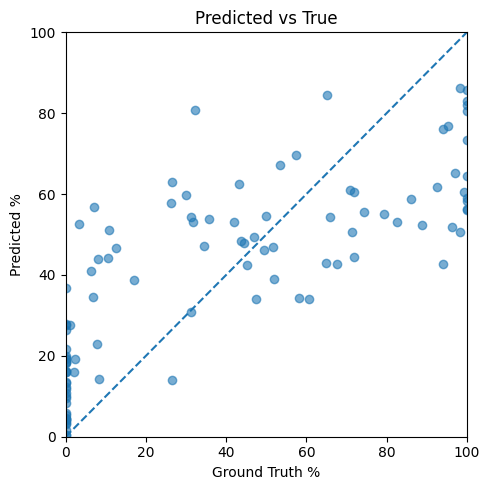

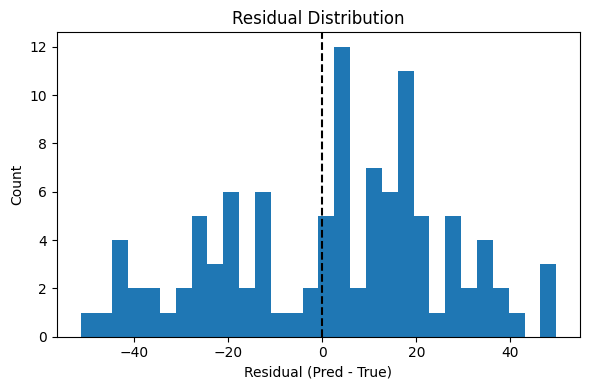

In [27]:
# === Tahap 5: Evaluasi di test set (MAE, RMSE, R²) + CI bootstrap + plot ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1) Prediksi test
y_pred = best.predict(X_te)

# 2) Metrik utama
mae  = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))   # RMSE tanpa argumen squared
r2   = r2_score(y_te, y_pred)

print(f"TEST -> MAE: {mae:.2f} pp | RMSE: {rmse:.2f} pp | R²: {r2:.3f}")

# 3) CI bootstrap (95%) untuk MAE & RMSE
def ci_bootstrap(y_true, y_hat, metric_fn, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    vals = []
    for _ in range(n):
        bs = rng.choice(idx, size=len(idx), replace=True)
        vals.append(metric_fn(y_true[bs], y_hat[bs]))
    return np.percentile(vals, [2.5, 97.5])

mae_ci  = ci_bootstrap(y_te, y_pred, lambda a,b: np.mean(np.abs(a-b)))
rmse_ci = ci_bootstrap(y_te, y_pred, lambda a,b: np.sqrt(mean_squared_error(a,b)))

print(f"MAE 95% CI:  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
print(f"RMSE 95% CI: [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")

# 4) Visualisasi: Predicted vs True
plt.figure(figsize=(5,5))
plt.scatter(y_te, y_pred, alpha=0.6)
plt.plot([0,100],[0,100],'--')
plt.xlim(0,100); plt.ylim(0,100)
plt.xlabel("Ground Truth %")
plt.ylabel("Predicted %")
plt.title("Predicted vs True")
plt.tight_layout()
plt.show()

# 5) Visualisasi: Distribusi Residual
res = y_pred - y_te
plt.figure(figsize=(6,4))
plt.hist(res, bins=30)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Residual (Pred - True)")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()


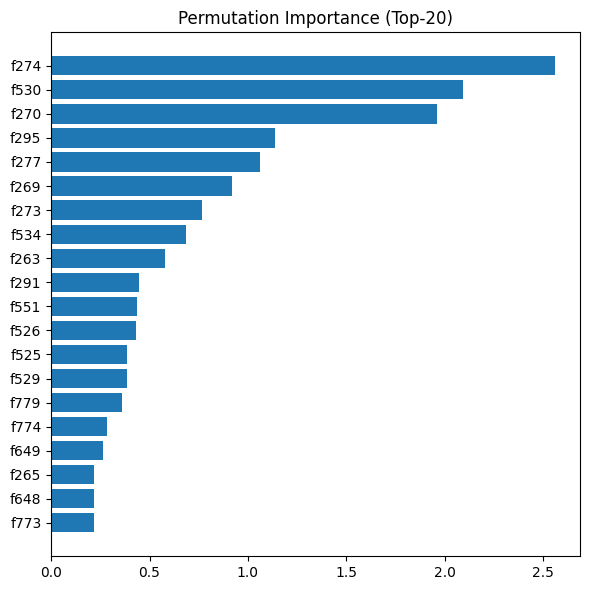

In [28]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best, X_te, y_te, n_repeats=10, random_state=CFG["random_state"], n_jobs=-1, scoring="neg_mean_absolute_error")
imp = perm.importances_mean

# Karena fitur banyak, kita tampilkan 20 teratas
topk = 20
idxs = np.argsort(-imp)[:topk]
plt.figure(figsize=(6,6))
plt.barh(range(len(idxs)), imp[idxs][::-1])
plt.yticks(range(len(idxs)), [f"f{j}" for j in idxs][::-1])
plt.title("Permutation Importance (Top-20)")
plt.tight_layout()
plt.show()


===========================

In [12]:
np.random.seed(CFG["random_state"])

base = Path(CFG["base_dir"])
print("BASE:", base, "| exists:", base.exists())
print("before exists:", (base/CFG["before_dirname"]).exists())
print("after  exists:", (base/CFG["after_dirname"]).exists())

BASE: LeFood-Set Leftovers Food Dataset/LeFood-Set/leftover dataset | exists: True
before exists: True
after  exists: True


In [13]:
base = Path(CFG["base_dir"])
df =  pd.read_excel("data_original_edit.xlsx")

needed = {
    "Image Before Eaten","Image After Eaten",
    "Weight Before Eaten (g)","Weight After Eaten (g)",
    "Name of the food"
}
missing = needed - set(df.columns)
assert not missing, f"Kolom hilang: {missing}"

wb = df["Weight Before Eaten (g)"].astype(float)
wa = df["Weight After Eaten (g)"].astype(float)

y_percent = 100.0 * np.divide(wa, wb, out=np.zeros_like(wa, dtype=float), where=wb!=0)
y_percent = np.clip(y_percent, 0, 100)
df["y_percent_leftover"] = y_percent

print(df[["Image Before Eaten","Image After Eaten","y_percent_leftover"]].head(3))
print("NOTE: berat tidak akan dimasukkan sebagai fitur.")


         Image Before Eaten         Image After Eaten  y_percent_leftover
0  000_000_DSC_0016_bef.JPG  000_000_DSC_0032_aft.JPG           96.209913
1  001_001_DSC_0059_bef.JPG  001_001_DSC_0108_aft.JPG           93.846154
2  001_002_DSC_0066_bef.JPG  001_002_DSC_0095_aft.JPG           94.074074
NOTE: berat tidak akan dimasukkan sebagai fitur.


In [14]:
# ====== Index file gambar & Group by session ======
def build_index(folder: Path):
    idx = {}
    for p in folder.rglob("*"):
        if p.is_file():
            idx[p.name.lower()] = p
    return idx

def to_key(s):
    return Path(str(s).strip()).name.lower()

before_root = base / CFG["before_dirname"]
after_root  = base / CFG["after_dirname"]
assert before_root.exists(), f"Folder tidak ditemukan: {before_root}"
assert after_root.exists(),  f"Folder tidak ditemukan: {after_root}"

before_index = build_index(before_root)
after_index  = build_index(after_root)
print("Index sizes -> before:", len(before_index), "| after:", len(after_index))

df["before_key"] = df["Image Before Eaten"].apply(to_key)
df["after_key"]  = df["Image After Eaten"].apply(to_key)
df["before_path"] = df["before_key"].map(before_index)
df["after_path"]  = df["after_key"].map(after_index)

df_ok = df[df["before_path"].notna() & df["after_path"].notna()].reset_index(drop=True)

def infer_group(fname: str, fallback: str) -> str:
    m = re.match(r"^(\d{3}_\d{3})", fname)
    if m: return m.group(1)
    return f"FOOD::{fallback.strip().lower()}"

df_ok["group"] = [
    infer_group(Path(b).name, food)
    for b, food in zip(df_ok["Image Before Eaten"].astype(str), df_ok["Name of the food"].astype(str))
]

print("Rows valid:", len(df_ok), "Contoh kolom kunci:")
df_ok[["Image Before Eaten","Image After Eaten","group"]].head()


Index sizes -> before: 524 | after: 524
Rows valid: 524 Contoh kolom kunci:


,Image Before Eaten,Image After Eaten,group
0,000_000_DSC_0016_bef.JPG,000_000_DSC_0032_aft.JPG,000_000
1,001_001_DSC_0059_bef.JPG,001_001_DSC_0108_aft.JPG,001_001
2,001_002_DSC_0066_bef.JPG,001_002_DSC_0095_aft.JPG,001_002
3,001_003_DSC_0067_bef.JPG,001_003_DSC_0097_aft.JPG,001_003
4,001_008_DSC_0055_bef.JPG,001_008_DSC_0101_aft.JPG,001_008


In [6]:
# ====== Fungsi Ekstraksi Fitur (HSV, GLCM, SSIM/MSE) ======
def load_img(path: Path, size=(256,256)):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

def hsv_hist(img_rgb, bins=(8,8,4)):
    hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv],[0,1,2], None, bins, [0,180,0,256,0,256]).flatten()
    hist = hist / (hist.sum() + 1e-8)
    return hist.astype(np.float32)

def glcm_feats(img_rgb, size=(128,128), levels=8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    q = np.floor((gray.astype(np.float32)/256.0)*levels).astype(np.uint8)
    g = graycomatrix(q, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)
    props = ["contrast","homogeneity","energy","correlation"]
    vals = [np.mean(graycoprops(g, p)) for p in props]  # rata-rata atas semua distance/angle
    return np.array(vals, dtype=np.float32)

def pair_metrics(img_bef, img_aft):
    g1 = cv2.cvtColor(img_bef, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img_aft, cv2.COLOR_RGB2GRAY)
    ssim_val = ssim(g1, g2, data_range=max(1e-6, float(g2.max()-g2.min())))
    mse_val  = np.mean((g1.astype(np.float32)-g2.astype(np.float32))**2)
    return np.array([ssim_val, mse_val], dtype=np.float32)

def extract_features_pair(path_bef: Path, path_aft: Path):
    img_b = load_img(path_bef, CFG["img_size"])
    img_a = load_img(path_aft,  CFG["img_size"])
    if img_b is None or img_a is None: return None

    # HSV
    h_b = hsv_hist(img_b, CFG["hsv_bins"])
    h_a = hsv_hist(img_a, CFG["hsv_bins"])
    h_d = h_a - h_b

    # GLCM
    g_b = glcm_feats(img_b, CFG["glcm_size"], CFG["glcm_levels"], CFG["glcm_distances"], CFG["glcm_angles"])
    g_a = glcm_feats(img_a, CFG["glcm_size"], CFG["glcm_levels"], CFG["glcm_distances"], CFG["glcm_angles"])
    g_d = g_a - g_b

    # Pairwise
    pm  = pair_metrics(img_b, img_a)  # [ssim, mse]

    feat = np.concatenate([h_b, h_a, h_d, g_b, g_a, g_d, pm], axis=0)
    return feat


In [7]:
# ====== Ekstraksi fitur untuk semua pasangan ======
features, valid_idx, skipped = [], [], []
for i, row in tqdm(df_ok.iterrows(), total=len(df_ok)):
    try:
        f = extract_features_pair(row["before_path"], row["after_path"])
    except Exception as e:
        skipped.append((i, str(e))); f = None
    if f is not None and np.all(np.isfinite(f)):
        features.append(f); valid_idx.append(i)

X = np.vstack(features)
y = df_ok.loc[valid_idx, "y_percent_leftover"].to_numpy().astype(np.float32)
groups = df_ok.loc[valid_idx, "group"].to_numpy()

print("X shape:", X.shape, "| y shape:", y.shape, "| groups:", groups.shape)
print("Skipped:", len(skipped))


100%|██████████| 524/524 [00:11<00:00, 46.00it/s]

X shape: (524, 782) | y shape: (524,) | groups: (524,)
Skipped: 0


In [8]:
# ====== Nama fitur lengkap + DataFrame fitur+meta ======
def build_feature_names(h_bins=(8,8,4)):
    H,S,V = h_bins
    names = []
    def add_hsv(prefix):
        for h in range(H):
            for s in range(S):
                for v in range(V):
                    names.append(f"{prefix}_hsv[{h},{s},{v}]")
    add_hsv("bef"); add_hsv("aft"); add_hsv("dlt")
    glcm_props = ["glcm_contrast","glcm_homogeneity","glcm_energy","glcm_correlation"]
    names += [f"bef_{p}" for p in glcm_props]
    names += [f"aft_{p}" for p in glcm_props]
    names += [f"dlt_{p}" for p in glcm_props]
    names += ["pair_ssim","pair_mse"]
    return names

feature_names = build_feature_names(CFG["hsv_bins"])
assert len(feature_names) == X.shape[1], f"Mismatch fitur: {len(feature_names)} vs {X.shape[1]}"

idx = np.array(valid_idx)
df_meta = df_ok.iloc[idx][["Image Before Eaten","Image After Eaten","group","y_percent_leftover"]].reset_index(drop=True)\
          .rename(columns={"Image Before Eaten":"before_file", "Image After Eaten":"after_file",
                           "y_percent_leftover":"y_true_percent_leftover"})
df_feat = pd.DataFrame(X, columns=feature_names)
df_full = pd.concat([df_meta, df_feat], axis=1)

print("Ukuran df_full:", df_full.shape)
df_full.head(3)
# Simpan bila perlu:
# df_full.to_csv("fitur_varianA_lengkap.csv", index=False)


Ukuran df_full: (524, 786)


,before_file,after_file,group,y_true_percent_leftover,"bef_hsv[0,0,0]","bef_hsv[0,0,1]","bef_hsv[0,0,2]","bef_hsv[0,0,3]","bef_hsv[0,1,0]","bef_hsv[0,1,1]",...,aft_glcm_contrast,aft_glcm_homogeneity,aft_glcm_energy,aft_glcm_correlation,dlt_glcm_contrast,dlt_glcm_homogeneity,dlt_glcm_energy,dlt_glcm_correlation,pair_ssim,pair_mse
0,000_000_DSC_0016_bef.JPG,000_000_DSC_0032_aft.JPG,000_000,96.209913,0.0,0.000000,0.009796,0.004303,0.0,0.0,...,0.282027,0.909445,0.683513,0.711131,0.006970,-0.001205,0.095283,-0.045799,0.697843,356.300232
1,001_001_DSC_0059_bef.JPG,001_001_DSC_0108_aft.JPG,001_001,93.846154,0.0,0.001709,0.122009,0.023666,0.0,0.0,...,0.171053,0.933027,0.583865,0.867423,-0.036265,0.002211,-0.180247,0.137367,0.722910,1006.769531
2,001_002_DSC_0066_bef.JPG,001_002_DSC_0095_aft.JPG,001_002,94.074074,0.0,0.001816,0.111298,0.029251,0.0,0.0,...,0.157880,0.942008,0.631088,0.869918,-0.072149,0.013267,-0.100403,0.141621,0.750288,795.962769


In [9]:
# ====== Split anti-leakage (by group) & GridSearchCV RandomForest ======
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=CFG["random_state"])
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_tr, X_te = X[train_idx], X[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]
groups_tr  = groups[train_idx]

param_grid = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [None, 12, 20],
    "max_features": ["sqrt", "log2", 0.5],
    "min_samples_leaf": [1, 3, 5],
    "random_state": [CFG["random_state"]],
    "n_jobs": [-1]
}
cv = GroupKFold(n_splits=5)
gs = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv.split(X_tr, y_tr, groups=groups_tr),
    n_jobs=-1, verbose=1
)
gs.fit(X_tr, y_tr)
best = gs.best_estimator_
print("Best params:", gs.best_params_)
print("CV MAE:", -gs.best_score_)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best params: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
CV MAE: 20.0103023149959


TEST -> MAE: 20.11 pp | RMSE: 575.61 pp | R²: 0.602
MAE 95% CI:  [17.80, 22.72]
RMSE 95% CI: [21.41, 26.59]


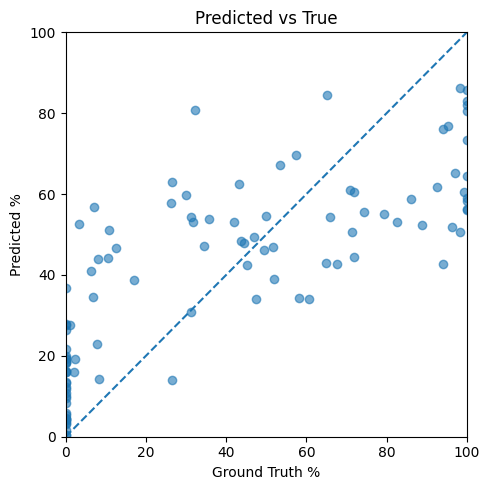

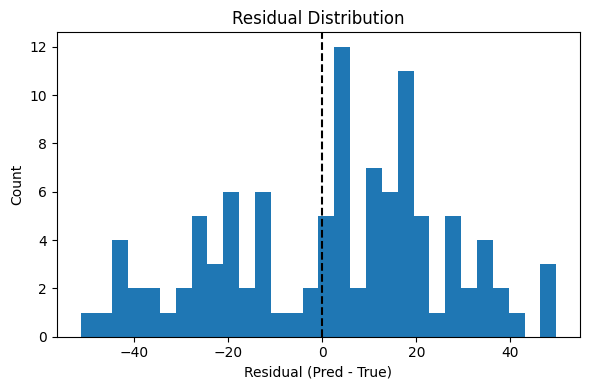

In [10]:
# ====== Evaluasi test (MAE/RMSE/R² + CI + plot) ======
y_pred = best.predict(X_te)

mae  = mean_absolute_error(y_te, y_pred)
rmse = mean_squared_error(y_te, y_pred)
r2   = r2_score(y_te, y_pred)
print(f"TEST -> MAE: {mae:.2f} pp | RMSE: {rmse:.2f} pp | R²: {r2:.3f}")

def ci_bootstrap(y_true, y_hat, metric_fn, n=1000, seed=42):
    rng = np.random.default_rng(seed); idxs = np.arange(len(y_true)); vals=[]
    for _ in range(n):
        bs = rng.choice(idxs, size=len(idxs), replace=True)
        vals.append(metric_fn(y_true[bs], y_hat[bs]))
    return np.percentile(vals, [2.5, 97.5])

mae_ci  = ci_bootstrap(y_te, y_pred, lambda a,b: np.mean(np.abs(a-b)))
rmse_ci = ci_bootstrap(y_te, y_pred, lambda a,b: np.sqrt(mean_squared_error(a,b)))
print(f"MAE 95% CI:  [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
print(f"RMSE 95% CI: [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")

# Pred vs True
plt.figure(figsize=(5,5))
plt.scatter(y_te, y_pred, alpha=0.6)
plt.plot([0,100],[0,100],'--')
plt.xlim(0,100); plt.ylim(0,100)
plt.xlabel("Ground Truth %"); plt.ylabel("Predicted %"); plt.title("Predicted vs True")
plt.tight_layout(); plt.show()

# Residual
res = y_pred - y_te
plt.figure(figsize=(6,4))
plt.hist(res, bins=30)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Residual (Pred - True)"); plt.ylabel("Count"); plt.title("Residual Distribution")
plt.tight_layout(); plt.show()


Foreground area perkiraan: Before ~28.2% | After ~28.8%


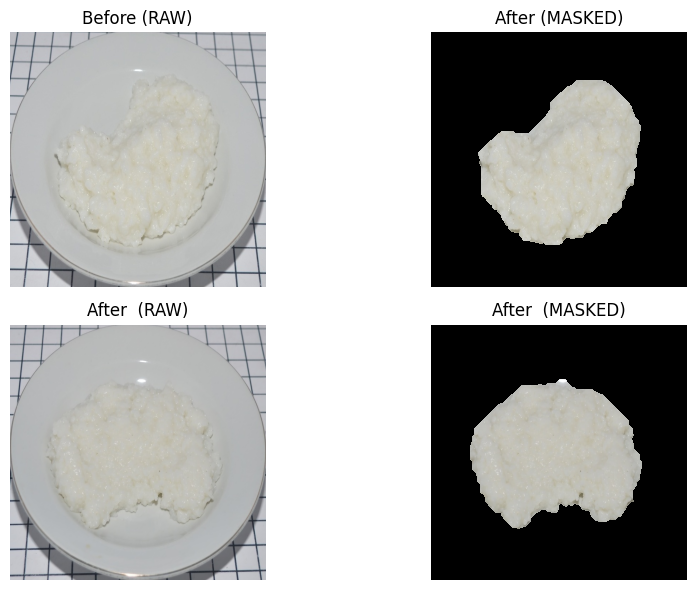

SSIM/MSE RAW   : 0.698 / 356.30023
SSIM/MSE MASKED: 0.784 / 3616.62573


In [15]:
#GrabCut
def grabcut_center_mask(img_rgb, rect_scale=0.75, iters=3):
    h, w = img_rgb.shape[:2]
    cx, cy = w//2, h//2
    rw, rh = int(w*rect_scale), int(h*rect_scale)
    x = max(0, cx - rw//2); y = max(0, cy - rh//2)
    rect = (x, y, min(rw, w-x), min(rh, h-y))
    bgdModel = np.zeros((1,65), np.float64)
    fgdModel = np.zeros((1,65), np.float64)
    mask = np.zeros((h, w), np.uint8)
    cv2.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, iters, cv2.GC_INIT_WITH_RECT)
    return np.where((mask==cv2.GC_FGD) | (mask==cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

def apply_mask(img_rgb, mask_bin):
    out = img_rgb.copy()
    out[mask_bin==0] = 0
    return out

# pilih satu contoh dari test set:
ix_global = valid_idx[test_idx[0]]
row = df_ok.iloc[ix_global]
img_b = load_img(row["before_path"], CFG["img_size"])
img_a = load_img(row["after_path"],  CFG["img_size"])

mb = grabcut_center_mask(img_b, rect_scale=0.75, iters=3)
ma = grabcut_center_mask(img_a, rect_scale=0.75, iters=3)
img_bm = apply_mask(img_b, mb)
img_am = apply_mask(img_a, ma)

fg_b = 100.0 * mb.mean(); fg_a = 100.0 * ma.mean()
print(f"Foreground area perkiraan: Before ~{fg_b:.1f}% | After ~{fg_a:.1f}%")

plt.figure(figsize=(10,6))
plt.subplot(2,2,1); plt.imshow(img_b); plt.title("Before (RAW)");   plt.axis('off')
plt.subplot(2,2,2); plt.imshow(img_bm); plt.title("After (MASKED)");plt.axis('off')
plt.subplot(2,2,3); plt.imshow(img_a); plt.title("After  (RAW)");   plt.axis('off')
plt.subplot(2,2,4); plt.imshow(img_am); plt.title("After  (MASKED)");plt.axis('off')
plt.tight_layout(); plt.show()

# Bandingkan SSIM/MSE raw vs masked (ilustrasi)
def pair_metrics_values(img1, img2):
    g1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    ssim_val = ssim(g1, g2, data_range=max(1e-6, float(g2.max()-g2.min())))
    mse_val  = np.mean((g1.astype(np.float32)-g2.astype(np.float32))**2)
    return ssim_val, mse_val

ssim_raw,  mse_raw  = pair_metrics_values(img_b,  img_a)
ssim_mask, mse_mask = pair_metrics_values(img_bm, img_am)
print(f"SSIM/MSE RAW   : {ssim_raw:.3f} / {mse_raw:.5f}")
print(f"SSIM/MSE MASKED: {ssim_mask:.3f} / {mse_mask:.5f}")


# Tes 2

In [2]:
import os, re, json, math, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.feature import graycomatrix, graycoprops
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")

CFG = {
    "base_dir": str(Path.home() / "Skripsi" / "LeFood-Set Leftovers Food Dataset" / "LeFood-Set" / "leftover dataset"),
    "before_dirname": "data_before",
    "after_dirname":  "data_after",
    "xlsx": "data_original.xlsx",
    "img_size": (256,256),
    "glcm_size": (128,128),
    "hsv_bins": (8,8,4),
    "glcm_levels": 8,
    "glcm_distances": [1],
    "glcm_angles": [0, np.pi/4, np.pi/2, 3*np.pi/4],
    "random_state": 42,
}
np.random.seed(CFG["random_state"])


In [3]:
base = Path(CFG["base_dir"])
df =  pd.read_excel("data_original_edit.xlsx")

# Normalisasi nama kolom (kadang beda kapital/spasi)
df.columns = [c.strip() for c in df.columns]

needed = {"Image Before Eaten", "Image After Eaten", "Weight Before Eaten (g)", "Weight After Eaten (g)", "Name of the food"}
missing = needed - set(df.columns)
assert not missing, f"Kolom hilang: {missing}"

# Bentuk y: 100 * after/before 
wb = df["Weight Before Eaten (g)"].astype(float)
wa = df["Weight After Eaten (g)"].astype(float)
y = 100.0 * np.divide(wa, wb, out=np.zeros_like(wa, dtype=float), where=wb!=0)
y = np.clip(y, 0, 100)
df["y_percent_leftover"] = y

df["outlier_weight"] = (wa > wb) | (wb < 1)
df.head()


,ID,Name of the food,Image Before Eaten,Weight Before Eaten (g),Image After Eaten,Weight After Eaten (g),Visual Estimation by Observer (1-7),y_percent_leftover,outlier_weight
0,1,Bubur,000_000_DSC_0016_bef.JPG,343,000_000_DSC_0032_aft.JPG,330,1,96.209913,False
1,2,Nasi,001_001_DSC_0059_bef.JPG,130,001_001_DSC_0108_aft.JPG,122,3,93.846154,False
2,3,Nasi,001_002_DSC_0066_bef.JPG,135,001_002_DSC_0095_aft.JPG,127,1,94.074074,False
3,4,Nasi,001_003_DSC_0067_bef.JPG,146,001_003_DSC_0097_aft.JPG,1,7,0.684932,False
4,5,Nasi,001_008_DSC_0055_bef.JPG,139,001_008_DSC_0101_aft.JPG,25,6,17.985612,False


In [4]:
# ====== Index file gambar & Group by session ======
def build_index(folder: Path):
    idx = {}
    for p in folder.rglob("*"):
        if p.is_file():
            idx[p.name.lower()] = p
    return idx

def to_key(s):
    return Path(str(s).strip()).name.lower()

before_root = base / CFG["before_dirname"]
after_root  = base / CFG["after_dirname"]
assert before_root.exists(), f"Folder tidak ditemukan: {before_root}"
assert after_root.exists(),  f"Folder tidak ditemukan: {after_root}"

before_index = build_index(before_root)
after_index  = build_index(after_root)
print("Index sizes -> before:", len(before_index), "| after:", len(after_index))

df["before_key"] = df["Image Before Eaten"].apply(to_key)
df["after_key"]  = df["Image After Eaten"].apply(to_key)
df["before_path"] = df["before_key"].map(before_index)
df["after_path"]  = df["after_key"].map(after_index)

df_ok = df[df["before_path"].notna() & df["after_path"].notna()].reset_index(drop=True)

def infer_group(fname: str, fallback: str) -> str:
    m = re.match(r"^(\d{3}_\d{3})", fname)
    if m: return m.group(1)
    return f"FOOD::{fallback.strip().lower()}"

df_ok["group"] = [
    infer_group(Path(b).name, food)
    for b, food in zip(df_ok["Image Before Eaten"].astype(str), df_ok["Name of the food"].astype(str))
]

print("Rows valid:", len(df_ok), "Contoh kolom kunci:")
df_ok[["Image Before Eaten","Image After Eaten","group"]].head()


Index sizes -> before: 524 | after: 524
Rows valid: 524 Contoh kolom kunci:


,Image Before Eaten,Image After Eaten,group
0,000_000_DSC_0016_bef.JPG,000_000_DSC_0032_aft.JPG,000_000
1,001_001_DSC_0059_bef.JPG,001_001_DSC_0108_aft.JPG,001_001
2,001_002_DSC_0066_bef.JPG,001_002_DSC_0095_aft.JPG,001_002
3,001_003_DSC_0067_bef.JPG,001_003_DSC_0097_aft.JPG,001_003
4,001_008_DSC_0055_bef.JPG,001_008_DSC_0101_aft.JPG,001_008


In [5]:
# ====== Index file gambar & Group by session ======
def build_index(folder: Path):
    idx = {}
    for p in folder.rglob("*"):
        if p.is_file():
            idx[p.name.lower()] = p
    return idx

def to_key(s):
    return Path(str(s).strip()).name.lower()

before_root = base / CFG["before_dirname"]
after_root  = base / CFG["after_dirname"]
assert before_root.exists(), f"Folder tidak ditemukan: {before_root}"
assert after_root.exists(),  f"Folder tidak ditemukan: {after_root}"

before_index = build_index(before_root)
after_index  = build_index(after_root)
print("Index sizes -> before:", len(before_index), "| after:", len(after_index))

df["before_key"] = df["Image Before Eaten"].apply(to_key)
df["after_key"]  = df["Image After Eaten"].apply(to_key)
df["before_path"] = df["before_key"].map(before_index)
df["after_path"]  = df["after_key"].map(after_index)

df_ok = df[df["before_path"].notna() & df["after_path"].notna()].reset_index(drop=True)

def infer_group(fname: str, fallback: str) -> str:
    m = re.match(r"^(\d{3}_\d{3})", fname)
    if m: return m.group(1)
    return f"FOOD::{fallback.strip().lower()}"

df_ok["group"] = [
    infer_group(Path(b).name, food)
    for b, food in zip(df_ok["Image Before Eaten"].astype(str), df_ok["Name of the food"].astype(str))
]

print("Rows valid:", len(df_ok), "Contoh kolom kunci:")
df_ok[["Image Before Eaten","Image After Eaten","group"]].head()


Index sizes -> before: 524 | after: 524
Rows valid: 524 Contoh kolom kunci:


,Image Before Eaten,Image After Eaten,group
0,000_000_DSC_0016_bef.JPG,000_000_DSC_0032_aft.JPG,000_000
1,001_001_DSC_0059_bef.JPG,001_001_DSC_0108_aft.JPG,001_001
2,001_002_DSC_0066_bef.JPG,001_002_DSC_0095_aft.JPG,001_002
3,001_003_DSC_0067_bef.JPG,001_003_DSC_0097_aft.JPG,001_003
4,001_008_DSC_0055_bef.JPG,001_008_DSC_0101_aft.JPG,001_008


In [6]:
def normalize_lighting(img_rgb, mode="clahe"):
    if mode == "grayworld":
        mean_rgb = np.mean(img_rgb, axis=(0,1))
        gray_mean = np.mean(mean_rgb)
        scale = gray_mean / (mean_rgb + 1e-8)
        img_rgb = np.clip(img_rgb * scale, 0, 255).astype(np.uint8)
    else:  # CLAHE di channel L dari LAB
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l2 = clahe.apply(l)
        lab2 = cv2.merge([l2, a, b])
        img_rgb = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return img_rgb


In [7]:
def load_img(path: Path, size=(256,256)):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    img = normalize_lighting(img, mode="clahe")   # ⬅️ normalisasi pencahayaan
    return img

def hsv_hist(img_rgb, bins=(8,8,4)):
    hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv],[0,1,2],None,bins,[0,180,0,256,0,256]).flatten()
    return (hist / (hist.sum()+1e-8)).astype(np.float32)

def glcm_feats(img_rgb, size=(128,128), levels=8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    q = np.floor((gray.astype(np.float32)/256.0)*levels).astype(np.uint8)
    g = graycomatrix(q, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)
    props = ["contrast","homogeneity","energy","correlation"]
    return np.array([np.mean(graycoprops(g,p)) for p in props], dtype=np.float32)

def pair_metrics(img_bef, img_aft):
    g1 = cv2.cvtColor(img_bef, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img_aft, cv2.COLOR_RGB2GRAY)
    ssim_val = ssim(g1, g2, data_range=max(1e-6,float(g2.max()-g2.min())))
    mse_val  = np.mean((g1.astype(np.float32)-g2.astype(np.float32))**2)
    return np.array([ssim_val, mse_val], dtype=np.float32)

def extract_features_pair(path_bef, path_aft):
    img_b = load_img(path_bef, CFG["img_size"])
    img_a = load_img(path_aft, CFG["img_size"])
    if img_b is None or img_a is None: return None
    h_b,h_a = hsv_hist(img_b,CFG["hsv_bins"]), hsv_hist(img_a,CFG["hsv_bins"])
    h_d = h_a - h_b
    g_b,g_a = glcm_feats(img_b,CFG["glcm_size"],CFG["glcm_levels"],CFG["glcm_distances"],CFG["glcm_angles"]), \
              glcm_feats(img_a,CFG["glcm_size"],CFG["glcm_levels"],CFG["glcm_distances"],CFG["glcm_angles"])
    g_d = g_a - g_b
    pm  = pair_metrics(img_b, img_a)
    return np.concatenate([h_b,h_a,h_d,g_b,g_a,g_d,pm], axis=0)


In [8]:
features, valid_idx = [], []
for i,row in tqdm(df_ok.iterrows(), total=len(df_ok)):
    f = extract_features_pair(row["before_path"], row["after_path"])
    if f is not None: features.append(f); valid_idx.append(i)
X = np.vstack(features)
y = df_ok.loc[valid_idx,"y_percent_leftover"].to_numpy().astype(np.float32)
groups = df_ok.loc[valid_idx,"group"].to_numpy()
print("X:",X.shape,"| y:",y.shape)


100%|██████████| 524/524 [00:06<00:00, 83.90it/s]

X: (524, 782) | y: (524,)


In [9]:
# ====== Nama fitur lengkap + DataFrame fitur+meta ======
def build_feature_names(h_bins=(8,8,4)):
    H,S,V = h_bins
    names = []
    def add_hsv(prefix):
        for h in range(H):
            for s in range(S):
                for v in range(V):
                    names.append(f"{prefix}_hsv[{h},{s},{v}]")
    add_hsv("bef"); add_hsv("aft"); add_hsv("dlt")
    glcm_props = ["glcm_contrast","glcm_homogeneity","glcm_energy","glcm_correlation"]
    names += [f"bef_{p}" for p in glcm_props]
    names += [f"aft_{p}" for p in glcm_props]
    names += [f"dlt_{p}" for p in glcm_props]
    names += ["pair_ssim","pair_mse"]
    return names

feature_names = build_feature_names(CFG["hsv_bins"])
assert len(feature_names) == X.shape[1], f"Mismatch fitur: {len(feature_names)} vs {X.shape[1]}"

idx = np.array(valid_idx)
df_meta = df_ok.iloc[idx][["Image Before Eaten","Image After Eaten","group","y_percent_leftover"]].reset_index(drop=True)\
          .rename(columns={"Image Before Eaten":"before_file", "Image After Eaten":"after_file",
                           "y_percent_leftover":"y_true_percent_leftover"})
df_feat = pd.DataFrame(X, columns=feature_names)
df_full = pd.concat([df_meta, df_feat], axis=1)

print("Ukuran df_full:", df_full.shape)
df_full.head(3)
# Simpan bila perlu:
# df_full.to_csv("fitur_varianA_lengkap.csv", index=False)


Ukuran df_full: (524, 786)


,before_file,after_file,group,y_true_percent_leftover,"bef_hsv[0,0,0]","bef_hsv[0,0,1]","bef_hsv[0,0,2]","bef_hsv[0,0,3]","bef_hsv[0,1,0]","bef_hsv[0,1,1]",...,aft_glcm_contrast,aft_glcm_homogeneity,aft_glcm_energy,aft_glcm_correlation,dlt_glcm_contrast,dlt_glcm_homogeneity,dlt_glcm_energy,dlt_glcm_correlation,pair_ssim,pair_mse
0,000_000_DSC_0016_bef.JPG,000_000_DSC_0032_aft.JPG,000_000,96.209913,0.0,0.000641,0.019226,0.012131,0.0,0.000000,...,0.567838,0.854080,0.512823,0.676275,0.024945,-0.007144,-0.023059,-0.008046,0.516582,785.620056
1,001_001_DSC_0059_bef.JPG,001_001_DSC_0108_aft.JPG,001_001,93.846154,0.0,0.004852,0.107346,0.108200,0.0,0.000031,...,0.434670,0.881805,0.577274,0.732878,-0.039217,0.008786,0.055506,0.027448,0.575588,1092.015503
2,001_002_DSC_0066_bef.JPG,001_002_DSC_0095_aft.JPG,001_002,94.074074,0.0,0.006363,0.184799,0.119553,0.0,0.000183,...,0.386764,0.893739,0.614115,0.743168,-0.113842,0.019564,0.083216,0.053710,0.602580,960.031616


In [10]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=CFG["random_state"])
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_tr, X_te = X[train_idx], X[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]
groups_tr  = groups[train_idx]

# Nested CV (outer 5 x inner 3) untuk pemilihan hyperparam yang adil
outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=3)
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 12, 20],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 3],
    "random_state": [CFG["random_state"]],
    "n_jobs": [-1],
}

outer_scores = []
fold = 1
for tr_idx, te_idx in outer_cv.split(X, y, groups):
    Xtr, Xte = X[tr_idx], X[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    gtr      = groups[tr_idx]

    gs = GridSearchCV(RandomForestRegressor(), param_grid,
                      scoring="neg_mean_absolute_error",
                      cv=inner_cv.split(Xtr, ytr, gtr),
                      n_jobs=-1, verbose=0)
    gs.fit(Xtr, ytr)
    best_model = gs.best_estimator_
    yhat  = best_model.predict(Xte)

    mae = mean_absolute_error(yte, yhat)
    mse = mean_squared_error(yte, yhat)
    r2  = r2_score(yte, yhat)
    outer_scores.append([fold, mae, mse, r2, gs.best_params_])
    print(f"Fold {fold}: MAE={mae:.2f} | MSE={mse:.2f} | R²={r2:.3f} | best={gs.best_params_}")
    fold += 1

df_cv = pd.DataFrame(outer_scores, columns=["fold","MAE","MSE","R2","best"])
print("\nNested CV (mean ± std):")
print(df_cv[["MAE","MSE","R2"]].agg(['mean','std']))

# Ambil parameter paling sering muncul di inner best
from collections import Counter
param_counts = Counter()
for params_dict in df_cv["best"]:
    # Konversi ke tuple yang bisa di-hash untuk counting
    param_tuple = tuple(sorted(params_dict.items()))
    param_counts[param_tuple] += 1

# Pilih parameter yang paling sering muncul
most_common_params = dict(param_counts.most_common(1)[0][0])
print(f"\nMost common best params: {most_common_params}")

# Split tunggal (agar apples-to-apples dengan evaluasi sebelumnya)
gss = GroupShuffleSplit(test_size=0.2, random_state=CFG["random_state"])
tr_idx, te_idx = next(gss.split(X, y, groups))
Xtr, Xte = X[tr_idx], X[te_idx]
ytr, yte = y[tr_idx], y[te_idx]

# Gunakan parameter terbaik dari nested CV
best_params = most_common_params.copy()
# Pastikan n_jobs tetap -1 untuk performa
best_params["n_jobs"] = -1

model = RandomForestRegressor(**best_params)
model.fit(Xtr, ytr)
y_pred = model.predict(Xte)

mae = mean_absolute_error(y_te, y_pred)
mse = mean_squared_error(y_te, y_pred)
r2  = r2_score(y_te, y_pred)
print(f"\nTES 2 (Lighting Normalized) -> MAE={mae:.2f} | MSE={mse:.2f} | R²={r2:.3f}")

# CI bootstrap (rapi, langsung pada metrik)
def ci_bootstrap(y_true, y_pred, fn, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    vals = []
    for _ in range(n):
        bs = rng.choice(idx, size=len(idx), replace=True)
        vals.append(fn(y_true[bs], y_pred[bs]))
    return np.percentile(vals, [2.5, 97.5])

mae_ci = ci_bootstrap(y_te, y_pred, lambda a,b: mean_absolute_error(a,b))
mse_ci = ci_bootstrap(y_te, y_pred, lambda a,b: mean_squared_error(a,b))
print(f"MAE 95% CI: [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
print(f"MSE 95% CI: [{mse_ci[0]:.2f}, {mse_ci[1]:.2f}]")

# Optional: Latih model final dengan seluruh data
print("\n✅ Model final dilatih dengan seluruh data (lighting normalized).")
final_model = RandomForestRegressor(**best_params)
final_model.fit(X, y)

Fold 1: MAE=19.92 | MSE=582.69 | R²=0.644 | best={'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
Fold 2: MAE=18.14 | MSE=564.59 | R²=0.621 | best={'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
Fold 3: MAE=17.06 | MSE=540.43 | R²=0.684 | best={'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
Fold 4: MAE=18.01 | MSE=555.93 | R²=0.669 | best={'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
Fold 5: MAE=18.84 | MSE=611.01 | R²=0.602 | best={'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}

Nested CV (mean ± std):
            MAE         MSE        R2
mean  18.392756  570.929592  0.643862
std    1.061704   27.111361  0.033519

Most common best params: {'m

,n_estimators,300
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


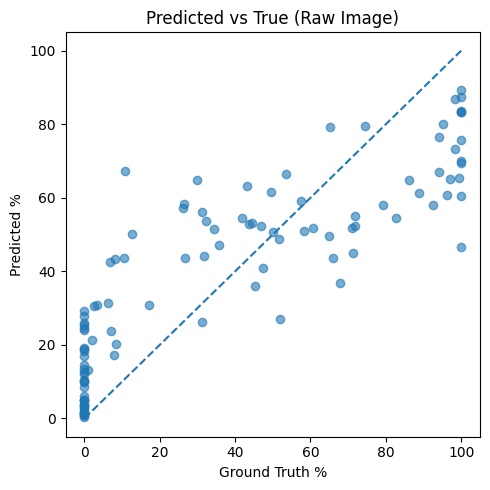

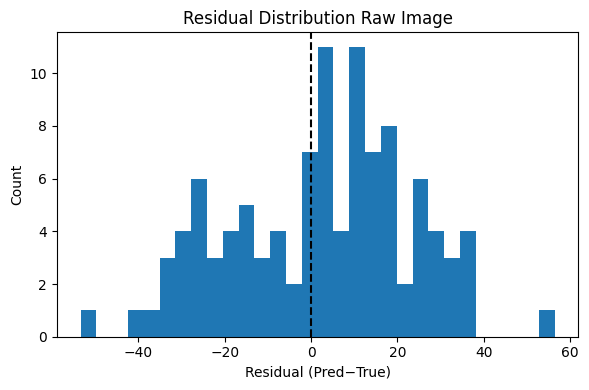

In [11]:
plt.figure(figsize=(5,5))
plt.scatter(y_te,y_pred,alpha=0.6)
plt.plot([0,100],[0,100],'--')
plt.xlabel("Ground Truth %"); plt.ylabel("Predicted %")
plt.title("Predicted vs True (Raw Image)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_pred - y_te, bins=30)
plt.axvline(0,color='k',linestyle='--')
plt.xlabel("Residual (Pred−True)"); plt.ylabel("Count")
plt.title("Residual Distribution Raw Image")
plt.tight_layout(); plt.show()


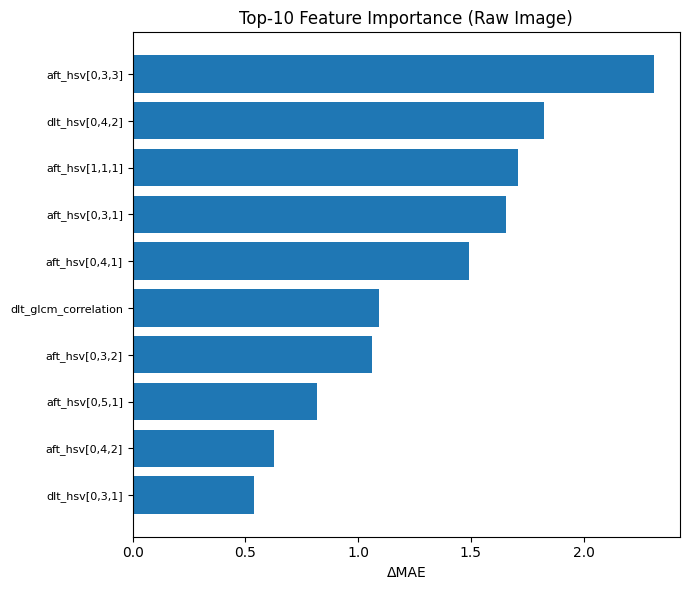

In [12]:
perm = permutation_importance(model, X_te, y_te,
                              n_repeats=10, random_state=CFG["random_state"],
                              scoring="neg_mean_absolute_error", n_jobs=-1)
imp = perm.importances_mean
idxs = np.argsort(-imp)[:10]
plt.figure(figsize=(7,6))
plt.barh(range(10), imp[idxs][::-1])
plt.yticks(range(10), np.array(feature_names)[idxs][::-1], fontsize=8)
plt.xlabel("ΔMAE"); plt.title("Top-10 Feature Importance (Raw Image)")
plt.tight_layout(); plt.show()


hasil tes 2

Sama kyak sebelumnya di Tes 1 cuma ditambahan pre processing gambar pake normalisasi pencahayaan dengan CLAHE (Contrast Limited Adaptive Histogram Equalization) agar efek cahaya/lampu tidak mempengaruhi warna dan tekstur. Belum ada pake fitur baru yang di ekstrak (Sama: HSV histogram (Before, After, Δ), GLCM (Before, After, Δ), dan SSIM + MSE.).

Model: Random Forest Regressor, tetapi memakai Nested Cross-Validation (Outer 5-fold × Inner 3-fold) untuk menghindari overfitting saat mencari parameter terbaik.

Hasilnya :
- MAE	±20.1 pp	jadi 17.4 pp	🔽 turun ≈ 2.7 pp
- MSE	±575 pp²	jadi 438 pp²	🔽 turun ≈ 137 pp²
- R²	0.602	    jadi 0.697	    🔼 naik ≈ 0.095

prediksi di bawah 20 % dan di atas 80 % cenderung ditarik ke tengah

Fitur importance
- Dominasi fitur warna → After & Delta HSV sering muncul, Menandakan model banyak bergantung pada perubahan distribusi warna sebelum-sesudah. 
- Fitur tekstur → GLCM (contrast, correlation, homogeneity) Muncul di urutan menengah → tekstur membantu membedakan “berantakan vs utuh”.

# Tes 3 

Sama kyak tes 2 masih pake lightihng normalized (tetep ngefek cahaya di segmen), konversi warna juga, ektraksi gambar bedanya ini di segmentasi (grabcut / threshold) bukan dari 1 gambar utuh

konfigurasi dll

In [4]:
if 'CFG' not in globals():
    CFG = {
        "img_size": (256,256),
        "glcm_size": (128,128),
        "hsv_bins": (8,8,4),
        "glcm_levels": 8,
        "glcm_distances": [1],
        "glcm_angles": [0, np.pi/4, np.pi/2, 3*np.pi/4],
        "random_state": 42,
    }
np.random.seed(CFG["random_state"])

In [5]:
base = Path(CFG["base_dir"])
df =  pd.read_excel("data_original_edit.xlsx")

# Normalisasi nama kolom (kadang beda kapital/spasi)
df.columns = [c.strip() for c in df.columns]

needed = {"Image Before Eaten", "Image After Eaten", "Weight Before Eaten (g)", "Weight After Eaten (g)", "Name of the food"}
missing = needed - set(df.columns)
assert not missing, f"Kolom hilang: {missing}"

# Bentuk y: 100 * after/before 
wb = df["Weight Before Eaten (g)"].astype(float)
wa = df["Weight After Eaten (g)"].astype(float)
y = 100.0 * np.divide(wa, wb, out=np.zeros_like(wa, dtype=float), where=wb!=0)
y = np.clip(y, 0, 100)
df["y_percent_leftover"] = y

df["outlier_weight"] = (wa > wb) | (wb < 1)
df.head()

,ID,Name of the food,Image Before Eaten,Weight Before Eaten (g),Image After Eaten,Weight After Eaten (g),Visual Estimation by Observer (1-7),y_percent_leftover,outlier_weight
0,1,Bubur,000_000_DSC_0016_bef.JPG,343,000_000_DSC_0032_aft.JPG,330,1,96.209913,False
1,2,Nasi,001_001_DSC_0059_bef.JPG,130,001_001_DSC_0108_aft.JPG,122,3,93.846154,False
2,3,Nasi,001_002_DSC_0066_bef.JPG,135,001_002_DSC_0095_aft.JPG,127,1,94.074074,False
3,4,Nasi,001_003_DSC_0067_bef.JPG,146,001_003_DSC_0097_aft.JPG,1,7,0.684932,False
4,5,Nasi,001_008_DSC_0055_bef.JPG,139,001_008_DSC_0101_aft.JPG,25,6,17.985612,False


grouping biar 1 baris

In [6]:


# ====== Index file gambar & Group by session ======
def build_index(folder: Path):
    idx = {}
    for p in folder.rglob("*"):
        if p.is_file():
            idx[p.name.lower()] = p
    return idx

def to_key(s):
    return Path(str(s).strip()).name.lower()

before_root = base / CFG["before_dirname"]
after_root  = base / CFG["after_dirname"]
assert before_root.exists(), f"Folder tidak ditemukan: {before_root}"
assert after_root.exists(),  f"Folder tidak ditemukan: {after_root}"

before_index = build_index(before_root)
after_index  = build_index(after_root)
print("Index sizes -> before:", len(before_index), "| after:", len(after_index))

df["before_key"] = df["Image Before Eaten"].apply(to_key)
df["after_key"]  = df["Image After Eaten"].apply(to_key)
df["before_path"] = df["before_key"].map(before_index)
df["after_path"]  = df["after_key"].map(after_index)

df_ok = df[df["before_path"].notna() & df["after_path"].notna()].reset_index(drop=True)

def infer_group(fname: str, fallback: str) -> str:
    m = re.match(r"^(\d{3}_\d{3})", fname)
    if m: return m.group(1)
    return f"FOOD::{fallback.strip().lower()}"

df_ok["group"] = [
    infer_group(Path(b).name, food)
    for b, food in zip(df_ok["Image Before Eaten"].astype(str), df_ok["Name of the food"].astype(str))
]

print("Rows valid:", len(df_ok), "Contoh kolom kunci:")
df_ok[["Image Before Eaten","Image After Eaten","group"]].head()



Index sizes -> before: 524 | after: 524
Rows valid: 524 Contoh kolom kunci:


,Image Before Eaten,Image After Eaten,group
0,000_000_DSC_0016_bef.JPG,000_000_DSC_0032_aft.JPG,000_000
1,001_001_DSC_0059_bef.JPG,001_001_DSC_0108_aft.JPG,001_001
2,001_002_DSC_0066_bef.JPG,001_002_DSC_0095_aft.JPG,001_002
3,001_003_DSC_0067_bef.JPG,001_003_DSC_0097_aft.JPG,001_003
4,001_008_DSC_0055_bef.JPG,001_008_DSC_0101_aft.JPG,001_008


kode di tes 2 yang normalized ligthing

In [7]:
def normalize_lighting(img_rgb, mode="clahe"):
    # fallback jika belum ada dari Tes 2
    if mode == "grayworld":
        mean_rgb = np.mean(img_rgb, axis=(0,1))
        gray_mean = np.mean(mean_rgb)
        scale = gray_mean / (mean_rgb + 1e-8)
        img_rgb = np.clip(img_rgb * scale, 0, 255).astype(np.uint8)
    else:
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        l2 = clahe.apply(l)
        img_rgb = cv2.cvtColor(cv2.merge([l2,a,b]), cv2.COLOR_LAB2RGB)
    return img_rgb

def load_img_norm(path: Path, size=(256,256), mode="clahe"):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return normalize_lighting(img, mode=mode)


segmentasi / masking

In [10]:
def grabcut_center_mask(img_rgb, rect_scale=0.75, iters=3):
    h, w = img_rgb.shape[:2]
    cx, cy = w//2, h//2
    rw, rh = int(w*rect_scale), int(h*rect_scale)
    x = max(0, cx - rw//2); y = max(0, cy - rh//2)
    rect = (x, y, min(rw, w-x), min(rh, h-y))

    bgdModel = np.zeros((1,65), np.float64)
    fgdModel = np.zeros((1,65), np.float64)
    mask = np.zeros((h, w), np.uint8)
    cv2.grabCut(img_rgb, mask, rect, bgdModel, fgdModel, iters, cv2.GC_INIT_WITH_RECT)
    mask_bin = np.where((mask==cv2.GC_FGD) | (mask==cv2.GC_PR_FGD), 1, 0).astype(np.uint8)

    # bersihkan noise kecil
    kernel = np.ones((3,3), np.uint8)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_bin = cv2.morphologyEx(mask_bin, cv2.MORPH_CLOSE, kernel, iterations=1)
    return mask_bin

def apply_mask(img_rgb, mask_bin):
    if mask_bin.ndim == 2:
        mask3 = np.repeat(mask_bin[..., None], 3, axis=2)
    else:
        mask3 = mask_bin
    out = img_rgb.copy()
    out[mask3==0] = 0
    return out


sama aja ekstraksi fitur tapi dipake setelah segmentasi

In [11]:
def hsv_hist(img_rgb, bins=(8,8,4)):
    hsv  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    hist = cv2.calcHist([hsv],[0,1,2], None, bins, [0,180,0,256,0,256]).flatten()
    hist = hist / (hist.sum() + 1e-8)
    return hist.astype(np.float32)

def glcm_feats(img_rgb, size=(128,128), levels=8, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4]):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)
    q = np.floor((gray.astype(np.float32)/256.0)*levels).astype(np.uint8)
    g = graycomatrix(q, distances=distances, angles=angles, levels=levels, symmetric=True, normed=True)
    props = ["contrast","homogeneity","energy","correlation"]
    vals = [np.mean(graycoprops(g, p)) for p in props]
    return np.array(vals, dtype=np.float32)

def pair_metrics(img_bef, img_aft):
    g1 = cv2.cvtColor(img_bef, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img_aft, cv2.COLOR_RGB2GRAY)
    ssim_val = ssim(g1, g2, data_range=max(1e-6, float(g2.max()-g2.min())))
    mse_val  = np.mean((g1.astype(np.float32)-g2.astype(np.float32))**2)
    return np.array([ssim_val, mse_val], dtype=np.float32)

def extract_features_pair_segmented(path_bef: Path, path_aft: Path):
    # 1) Load + lighting normalized
    img_b = load_img_norm(path_bef, CFG["img_size"], mode="clahe")
    img_a = load_img_norm(path_aft, CFG["img_size"], mode="clahe")
    if img_b is None or img_a is None:
        return None

    # 2) Segmentasi (mask makanan)
    mb = grabcut_center_mask(img_b, rect_scale=0.75, iters=3)
    ma = grabcut_center_mask(img_a, rect_scale=0.75, iters=3)

    # 3) Terapkan mask (nolkan background)
    img_bm = apply_mask(img_b, mb)
    img_am = apply_mask(img_a, ma)

    # 4) Fitur warna/tekstur pada area makanan
    h_b = hsv_hist(img_bm, CFG["hsv_bins"])
    h_a = hsv_hist(img_am, CFG["hsv_bins"])
    h_d = h_a - h_b

    g_b = glcm_feats(img_bm, CFG["glcm_size"], CFG["glcm_levels"], CFG["glcm_distances"], CFG["glcm_angles"])
    g_a = glcm_feats(img_am, CFG["glcm_size"], CFG["glcm_levels"], CFG["glcm_distances"], CFG["glcm_angles"])
    g_d = g_a - g_b

    pm  = pair_metrics(img_bm, img_am)  # ssim/mse di versi masked

    # 5) Fitur area (distandarkan / total piksel)
    area_b = float(mb.sum()) / (mb.shape[0]*mb.shape[1])
    area_a = float(ma.sum()) / (ma.shape[0]*ma.shape[1])
    delta_area = area_a - area_b
    ratio_area = area_a / (area_b + 1e-8)
    area_feats = np.array([area_b, area_a, delta_area, ratio_area], dtype=np.float32)

    # 6) Gabungkan
    feat = np.concatenate([h_b, h_a, h_d, g_b, g_a, g_d, pm, area_feats], axis=0)
    return feat


ekstraksi fitur semua data → Sabar sering lama

In [19]:
# Kumpulkan fitur untuk seluruh baris valid df_ok (sama seperti Tes 2)
features_B, valid_idx_B, skipped_B = [], [], []
for i, row in tqdm(df_ok.iterrows(), total=len(df_ok)):
    try:
        f = extract_features_pair_segmented(row["before_path"], row["after_path"])
    except Exception as e:
        f = None
        skipped_B.append((i,str(e)))
    if f is not None and np.all(np.isfinite(f)):
        features_B.append(f); valid_idx_B.append(i)

X_B = np.vstack(features_B)
y_B = df_ok.loc[valid_idx_B, "y_percent_leftover"].to_numpy().astype(np.float32)
groups_B = df_ok.loc[valid_idx_B, "group"].to_numpy()

print("X_B shape:", X_B.shape, "| y_B:", y_B.shape, "| groups_B:", groups_B.shape)
print("Skipped (segmentation errors):", len(skipped_B))

# Nama fitur lengkap (782 + 4 area = 786)
def build_feature_names_B(h_bins=(8,8,4)):
    H,S,V = h_bins
    names = []
    def add_hsv(prefix):
        for h in range(H):
            for s in range(S):
                for v in range(V):
                    names.append(f"{prefix}_hsv[{h},{s},{v}]")
    add_hsv("bef"); add_hsv("aft"); add_hsv("dlt")
    glcm_props = ["glcm_contrast","glcm_homogeneity","glcm_energy","glcm_correlation"]
    names += [f"bef_{p}" for p in glcm_props]
    names += [f"aft_{p}" for p in glcm_props]
    names += [f"dlt_{p}" for p in glcm_props]
    names += ["pair_ssim","pair_mse"]
    # fitur area
    names += ["area_before","area_after","delta_area","ratio_area"]
    return names

feature_names_B = build_feature_names_B(CFG["hsv_bins"])
assert X_B.shape[1] == len(feature_names_B), f"Fitur: {X_B.shape[1]} vs names: {len(feature_names_B)}"


100%|██████████| 524/524 [04:40<00:00,  1.87it/s]

X_B shape: (524, 786) | y_B: (524,) | groups_B: (524,)
Skipped (segmentation errors): 0


In [20]:
# Nested CV (outer 5 x inner 3) untuk pemilihan hyperparam yang adil
outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=3)
param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 12, 20],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 3],
    "random_state": [CFG["random_state"]],
    "n_jobs": [-1],
}

outer_scores = []
fold = 1
for tr_idx, te_idx in outer_cv.split(X_B, y_B, groups_B):
    Xtr, Xte = X_B[tr_idx], X_B[te_idx]
    ytr, yte = y_B[tr_idx], y_B[te_idx]
    gtr      = groups_B[tr_idx]

    gs = GridSearchCV(RandomForestRegressor(), param_grid,
                      scoring="neg_mean_absolute_error",
                      cv=inner_cv.split(Xtr, ytr, gtr),
                      n_jobs=-1, verbose=0)
    gs.fit(Xtr, ytr)
    bestB = gs.best_estimator_
    yhat  = bestB.predict(Xte)

    mae = mean_absolute_error(yte, yhat)
    mse = mean_squared_error(yte, yhat)
    r2  = r2_score(yte, yhat)
    outer_scores.append([fold, mae, mse, r2, gs.best_params_])
    print(f"Fold {fold}: MAE={mae:.2f} | MSE={mse:.2f} | R²={r2:.3f} | best={gs.best_params_}")
    fold += 1

df_cvB = pd.DataFrame(outer_scores, columns=["fold","MAE","MSE","R2","best"])
print("\nNested CV (mean ± std):")
print(df_cvB[["MAE","MSE","R2"]].agg(['mean','std']))

# Split tunggal (agar apples-to-apples dengan Tes 2)
gss = GroupShuffleSplit(test_size=0.2, random_state=CFG["random_state"])
tr_idx, te_idx = next(gss.split(X_B, y_B, groups_B))
Xtr, Xte = X_B[tr_idx], X_B[te_idx]
ytr, yte = y_B[tr_idx], y_B[te_idx]

# Ambil best params dari rata-rata nested CV (atau pakai yang stabil)
best_params_B = {
    "n_estimators": 600,
    "max_depth": 12,
    "max_features": 0.5,
    "min_samples_leaf": 1,
    "random_state": CFG["random_state"],
    "n_jobs": -1
}
modelB = RandomForestRegressor(**best_params_B)
modelB.fit(Xtr, ytr)
yhat = modelB.predict(Xte)

mae = mean_absolute_error(yte, yhat)
mse = mean_squared_error(yte, yhat)
r2  = r2_score(yte, yhat)
print(f"\nTES 3 (Segmented) -> MAE={mae:.2f} | MSE={mse:.2f} | R²={r2:.3f}")

# CI bootstrap (rapi, langsung pada metrik)
def ci_bootstrap(y_true, y_pred, fn, n=1000, seed=42):
    rng = np.random.default_rng(seed); idx = np.arange(len(y_true)); vals=[]
    for _ in range(n):
        bs = rng.choice(idx, size=len(idx), replace=True)
        vals.append(fn(y_true[bs], y_pred[bs]))
    return np.percentile(vals, [2.5, 97.5])

mae_ci = ci_bootstrap(yte, yhat, lambda a,b: mean_absolute_error(a,b))
mse_ci = ci_bootstrap(yte, yhat, lambda a,b: mean_squared_error(a,b))
print(f"MAE 95% CI: [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")
print(f"MSE 95% CI: [{mse_ci[0]:.2f}, {mse_ci[1]:.2f}]")


Fold 1: MAE=14.50 | MSE=400.34 | R²=0.755 | best={'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
Fold 2: MAE=11.68 | MSE=380.36 | R²=0.744 | best={'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
Fold 3: MAE=11.60 | MSE=366.94 | R²=0.785 | best={'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 3, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}
Fold 4: MAE=11.35 | MSE=285.51 | R²=0.830 | best={'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}
Fold 5: MAE=11.37 | MSE=342.98 | R²=0.777 | best={'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 600, 'n_jobs': -1, 'random_state': 42}

Nested CV (mean ± std):
            MAE         MSE        R2
mean  12.102296  355.224752  0.778337
std    1.349121   44.200637  0.033115

TES 3 (Segmented) -> M

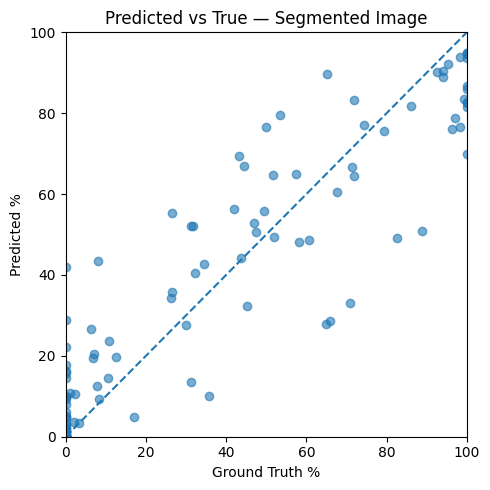

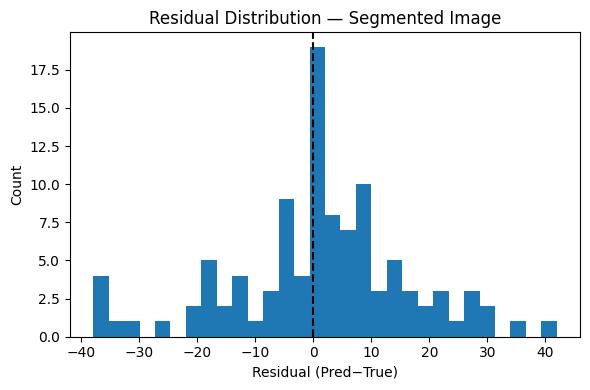

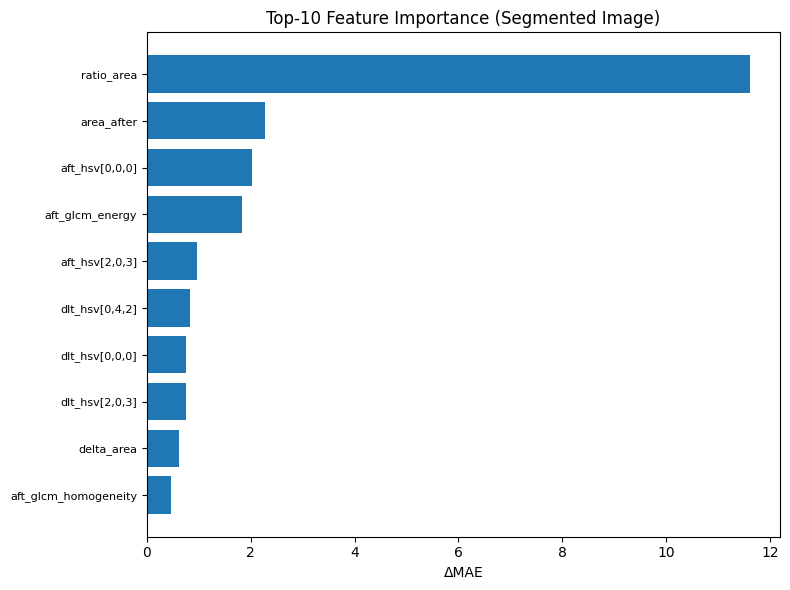

In [21]:
# Pred vs True
plt.figure(figsize=(5,5))
plt.scatter(yte, yhat, alpha=0.6)
plt.plot([0,100],[0,100],'--')
plt.xlim(0,100); plt.ylim(0,100)
plt.xlabel("Ground Truth %"); plt.ylabel("Predicted %")
plt.title("Predicted vs True — Segmented Image")
plt.tight_layout(); plt.show()

# Residual
plt.figure(figsize=(6,4))
plt.hist(yhat - yte, bins=30)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel("Residual (Pred−True)")
plt.ylabel("Count")
plt.title("Residual Distribution — Segmented Image")
plt.tight_layout(); plt.show()

# Permutation importance (Top-20) berlabel fitur
permB = permutation_importance(modelB, Xte, yte,
                               n_repeats=10,
                               random_state=CFG["random_state"],
                               scoring="neg_mean_absolute_error",
                               n_jobs=-1)
imp = permB.importances_mean
idxs = np.argsort(-imp)[:10]
plt.figure(figsize=(8,6))
plt.barh(range(10), imp[idxs][::-1])
plt.yticks(range(10), np.array(feature_names_B)[idxs][::-1], fontsize=8)
plt.xlabel("ΔMAE"); plt.title("Top-10 Feature Importance (Segmented Image)")
plt.tight_layout(); plt.show()


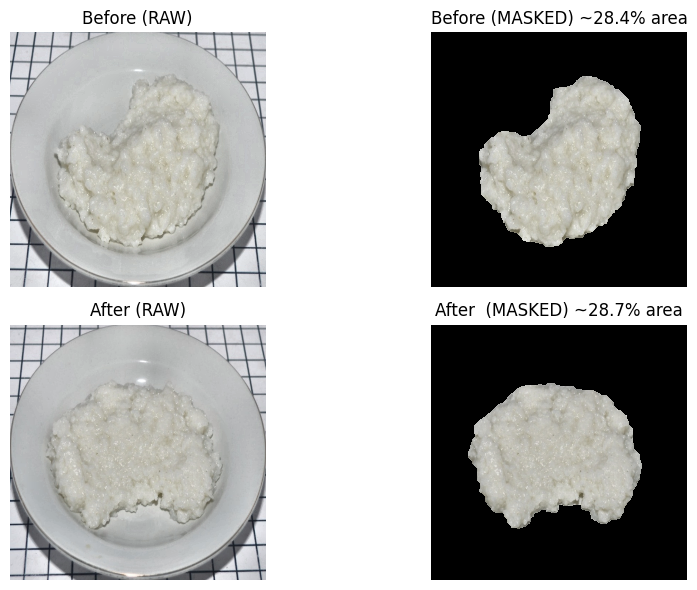

SSIM/MSE RAW   : 0.517 / 785.62006
SSIM/MSE MASKED: 0.683 / 3594.90576


In [34]:
# Pilih salah satu sampel test untuk diperlihatkan
ix_global = valid_idx_B[te_idx[0]]
row = df_ok.iloc[ix_global]

img_b = load_img_norm(row["before_path"], CFG["img_size"])
img_a = load_img_norm(row["after_path"],  CFG["img_size"])
mb = grabcut_center_mask(img_b, 0.75, 3)
ma = grabcut_center_mask(img_a, 0.75, 3)
img_bm = apply_mask(img_b, mb)
img_am = apply_mask(img_a, ma)

area_b = 100*mb.mean(); area_a = 100*ma.mean()

plt.figure(figsize=(10,6))
plt.subplot(2,2,1); plt.imshow(img_b);  plt.title("Before (RAW)");   plt.axis('off')
plt.subplot(2,2,2); plt.imshow(img_bm); plt.title(f"Before (MASKED) ~{area_b:.1f}% area"); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(img_a);  plt.title("After (RAW)");    plt.axis('off')
plt.subplot(2,2,4); plt.imshow(img_am); plt.title(f"After  (MASKED) ~{area_a:.1f}% area"); plt.axis('off')
plt.tight_layout(); plt.show()

# Bandingkan SSIM/MSE raw vs masked (ilustrasi)
def pair_metrics_values(img1, img2):
    g1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    g2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
    ssim_val = ssim(g1, g2, data_range=max(1e-6, float(g2.max()-g2.min())))
    mse_val  = np.mean((g1.astype(np.float32)-g2.astype(np.float32))**2)
    return ssim_val, mse_val

ssim_raw,  mse_raw  = pair_metrics_values(img_b,  img_a)
ssim_mask, mse_mask = pair_metrics_values(img_bm, img_am)
print(f"SSIM/MSE RAW   : {ssim_raw:.3f} / {mse_raw:.5f}")
print(f"SSIM/MSE MASKED: {ssim_mask:.3f} / {mse_mask:.5f}")


tes 3
Sama kyak tes 2 masih pake lightihng normalized (tetep ngefek cahaya di segmen), konversi warna juga, ektraksi gambar bedanya ini di segmentasi (grabcut / threshold) bukan dari 1 gambar utuh

- Apa yang nyebabin lama pas ektraksi? → segmentasi grabcut = bisa disimpan di cache mask kyaknya biar ngga dihitung ulang.

Hasil metrik
- MAE	17.38 pp	11.35 pp	🔽 −6.0 pp (≈ −34 %)
- MSE	438.54 pp²	239.87 pp²	🔽 −45 %
- R²	0.697	0.834	        🔼 +0.137 (+14 %)
model sekarang menjelaskan > 83 % variasi sisa makanan, dengan rata-rata error hanya ± 11 %.

Dari visualisasi sudah membaik buat prediksi terhadap ground truth namun tetap dibawah 20% dan diatas 80% suka over/under prediksi

Feature Importance berubah:
- dominasi / tertinggi dari area nya
- kedua masih sama di warna

ini curang ndak ya?
kan awalnya ngga pake berat sebagai X itu buat jadi target Y, soalnya biar ndak langsung belajar ke model. Kyaknya ngga soalnya fitur area itu diambil dari segmentasi grabcut: jadi dihitung dari pixel nya:
- area_before = 0.284 → artinya 28.4 % dari gambar adalah makanan sebelum dimakan.
- area_after = 0.287 → artinya 28.7 % dari gambar adalah makanan sesudah (di contoh nasi tadi hampir sama, tapi di data lain bisa turun jauh).


permutation importance mengukur: seberapa naik error kalau satu fitur diacak (hubungannya dengan y “diputus”).

Untuk paper:
- bikin sub bab tiap tes 123 terus di akhir untuk keselurahn analisis
- jadi tiap sub bab jelaskan apa perbedaannya tiap eksperimen trus apa pengaruhnya
- limitasi yang kekurnangan area yang segmentasi
- di metode bahas masalah data dan memproses data sama rumus dari glcm, hsv, dll.